# Solar Power Prediction — Improved Two-Stage Pipeline
## VIT Chennai 250 kW SEMS

**Architecture:**
- **Stage 1 (Irradiance Estimator):** Weather variables + sun-position geometry → estimated irradiance  
- **Stage 2 (Power Predictor):** All weather + estimated irradiance → output power (kW)

**At prediction time only weather variables are needed** — irradiance is estimated internally from weather + computed solar geometry (latitude/longitude/timestamp).



In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 1. Configuration

In [69]:
# ── File path ──────────────────────────────────────────────────────────────
FILE_PATH   = r"C:\\Solar_SUDHA_maam\\merged_output.csv"   # your merged dataset

# ── System constants ───────────────────────────────────────────────────────
LATITUDE    = 13.04          # VIT Chennai latitude  (degrees N)
LONGITUDE   = 80.17          # VIT Chennai longitude (degrees E)
RATED_KW    = 250            # system rated capacity (kW)
AREA_EFF_M2 = 181.591        # panel_area × efficiency (m²) — from physics calibration

# ── Train / test split ─────────────────────────────────────────────────────
TRAIN_END   = "2024-12-28"   # exclusive upper bound for training

# ── XGBoost hyperparameters ────────────────────────────────────────────────
IRR_PARAMS = dict(
    n_estimators     = 1000,
    max_depth        = 7,
    learning_rate    = 0.03,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 1,
    reg_lambda       = 3,
    min_child_weight = 3,
    random_state     = 42,
)

POWER_PARAMS = dict(
    n_estimators     = 1500,
    max_depth        = 6,
    learning_rate    = 0.03,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 2,
    reg_lambda       = 5,
    min_child_weight = 3,
    random_state     = 42,
)


## 2. Load & inspect data

In [70]:
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip().str.lower()
df["time"] = pd.to_datetime(df["time"], dayfirst=True)
df = df.sort_values("time").reset_index(drop=True)

print(f"Shape       : {df.shape}")
print(f"Date range  : {df['time'].min()}  →  {df['time'].max()}")
print(f"Columns     : {df.columns.tolist()}")
print()
df.head()


Shape       : (135186, 8)
Date range  : 2022-01-08 06:25:00  →  2026-04-12 12:15:00
Columns     : ['time', 'irradiance', 'power', 'theoretical_power', 'temp', 'humidity', 'wind_speed', 'precipitation']



,time,irradiance,power,theoretical_power,temp,humidity,wind_speed,precipitation
0,2022-01-08 06:25:00,0,0.000,0.00000,28.1,63.0,15.766,0.0039
1,2022-01-08 06:30:00,0,0.000,0.00000,28.1,63.0,15.812,0.0156
2,2022-01-08 06:35:00,0,0.653,0.00000,28.1,63.0,15.856,0.0210
3,2022-01-08 06:40:00,10,0.747,1.90347,28.1,63.0,15.895,0.0162
4,2022-01-08 06:45:00,10,0.891,1.90347,28.1,63.0,15.930,0.0190


## 3. Feature engineering

### 3a. Cyclical time features

In [71]:
df["hour"]      = df["time"].dt.hour + df["time"].dt.minute / 60
df["dayofyear"] = df["time"].dt.dayofyear
df["month"]     = df["time"].dt.month

# Cyclical encodings — ensures continuity at boundaries (23→0h, Dec→Jan)
for col, period in [("hour", 24), ("dayofyear", 365), ("month", 12)]:
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

print("Cyclical features added.")


Cyclical features added.


### 3b. Solar geometry
Computed purely from latitude, longitude, and timestamp — no irradiance sensor needed at prediction time.
Formulas used:
- Solar declination
- Solar elevation angle
- Clear-sky irradiance = 1000 × sin(elevation)

In [72]:
lat_rad = np.radians(LATITUDE)

# Solar declination (degrees) — Spencer approximation
declination = np.radians(23.45) * np.sin(np.radians((360 / 365) * (df["dayofyear"] - 81)))

# Hour angle: 0° at solar noon, ±15° per hour
hour_angle = np.radians(15 * (df["hour"] - 12))

# Sine of solar elevation angle
sin_elev = (np.sin(lat_rad) * np.sin(declination)
          + np.cos(lat_rad) * np.cos(declination) * np.cos(hour_angle))

df["solar_elevation"] = np.degrees(np.arcsin(np.clip(sin_elev, -1, 1)))

# Clear-sky irradiance: theoretical irradiance under perfectly clear sky (W/m²)
# This is the single most powerful feature — it encodes sun position perfectly
df["clear_sky_irr"] = np.clip(1000 * sin_elev, 0, 1100)

# Clear-sky theoretical power (kW) — the physics ceiling for power output
df["clear_sky_power"] = df["clear_sky_irr"] * AREA_EFF_M2 / 1000

print(df[["time", "solar_elevation", "clear_sky_irr", "clear_sky_power"]].head(8).to_string(index=False))


               time  solar_elevation  clear_sky_irr  clear_sky_power
2022-01-08 06:25:00         0.716229      12.500230         2.269929
2022-01-08 06:30:00         1.835071      32.022562         5.815009
2022-01-08 06:35:00         2.951402      51.488900         9.349921
2022-01-08 06:40:00         4.065106      70.889979        12.872982
2022-01-08 06:45:00         5.176066      90.216566        16.382516
2022-01-08 06:50:00         6.284157     109.459461        19.876853
2022-01-08 06:55:00         7.389248     128.609506        23.354329
2022-01-08 07:00:00         8.491205     147.657587        26.813289


### 3c. Cloud attenuation factor

`cloud_factor = actual_irradiance / clear_sky_irradiance`

This is the **target of Stage 1** — it represents how much the clouds reduce the theoretical maximum. Values: 0 (fully overcast) → 1 (perfectly clear) → >1 (possible reflected/scattered light enhancement).

In [73]:
# Only defined when sun is above horizon
df["cloud_factor"] = np.where(
    df["clear_sky_irr"] > 10,
    (df["irradiance"] / df["clear_sky_irr"]).clip(0, 1.2),
    np.nan
)

print("Cloud factor statistics:")
print(df["cloud_factor"].describe().round(3))
print()
print("Correlation of cloud_factor with weather variables:")
print(df[["humidity", "precipitation", "wind_speed", "temp", "cloud_factor"]]
      .corr()["cloud_factor"].round(3))


Cloud factor statistics:
count    128523.000
mean          0.299
std           0.210
min           0.000
25%           0.120
50%           0.280
75%           0.479
max           1.200
Name: cloud_factor, dtype: float64

Correlation of cloud_factor with weather variables:
humidity         0.044
precipitation   -0.070
wind_speed      -0.046
temp            -0.068
cloud_factor     1.000
Name: cloud_factor, dtype: float64


## 4. Data cleaning

In [74]:
df = df.replace([np.inf, -np.inf], np.nan)

# Single clean drop — removes rows missing any required variable
required_cols = ["power", "temp", "humidity", "wind_speed", "precipitation"]
before = len(df)
df = df.dropna(subset=required_cols).reset_index(drop=True)
after  = len(df)

print(f"Rows before cleaning : {before:,}")
print(f"Rows after  cleaning : {after:,}  ({before - after} dropped)")
print(f"NaN in power         : {df['power'].isna().sum()}")
print(f"Power range          : [{df['power'].min():.3f}, {df['power'].max():.3f}] kW")


Rows before cleaning : 135,186
Rows after  cleaning : 135,186  (0 dropped)
NaN in power         : 0
Power range          : [0.000, 43.625] kW


## 5. Temporal train / test split

Using a **calendar cutoff** (not random) because solar data is a time series — random splitting would leak future information into training.

In [75]:
train = df[df["time"] <  TRAIN_END].copy()
test  = df[df["time"] >= TRAIN_END].copy()

print(f"Training set : {len(train):>7,} rows  |  {train['time'].min().date()} → {train['time'].max().date()}")
print(f"Test set     : {len(test):>7,} rows  |  {test['time'].min().date()} → {test['time'].max().date()}")

# Daytime-only subsets (for focused evaluation)
train_day = train[train["clear_sky_irr"] > 10]
test_day  = test[test["clear_sky_irr"]   > 10]
print(f"\nDaytime rows  (train): {len(train_day):,}")
print(f"Daytime rows  (test) : {len(test_day):,}")


Training set :  75,337 rows  |  2022-01-08 → 2024-12-26
Test set     :  59,849 rows  |  2024-12-28 → 2026-04-12

Daytime rows  (train): 71,656
Daytime rows  (test) : 56,867


## 6. Feature definitions

All features listed below are available at **prediction time** — they require only weather forecast data and the timestamp (for solar geometry).

In [76]:
# Features available at prediction time (weather forecast + computed solar geometry)
WEATHER_TIME_FEATS = [
    "temp", "humidity", "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",
    "month_sin", "month_cos",
    "solar_elevation",          # computed from lat/lon/time — no sensor needed
]

# Additional physics features for the power model
# (irr_est and cf_est are outputs of Stage 1, also available at prediction time)
POWER_FEATS = WEATHER_TIME_FEATS + [
    "clear_sky_irr",    # theoretical maximum irradiance (physics-based)
    "clear_sky_power",  # theoretical maximum power (kW)
    "irr_est",          # Stage-1 estimated irradiance (W/m²)
    "theo_est",         # estimated theoretical power from Stage-1 irradiance
    "cf_est",           # estimated cloud attenuation factor
]

print("Stage-1 (irradiance estimator) input features:")
print(WEATHER_TIME_FEATS)
print()
print("Stage-2 (power predictor) input features:")
print(POWER_FEATS)


Stage-1 (irradiance estimator) input features:
['temp', 'humidity', 'wind_speed', 'precipitation', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos', 'month_sin', 'month_cos', 'solar_elevation']

Stage-2 (power predictor) input features:
['temp', 'humidity', 'wind_speed', 'precipitation', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos', 'month_sin', 'month_cos', 'solar_elevation', 'clear_sky_irr', 'clear_sky_power', 'irr_est', 'theo_est', 'cf_est']


## 7.Irradiance estimator
**Goal:** Learn to predict `cloud_factor` (or directly `irradiance`) from weather + solar geometry.
Then: `irr_est = clear_sky_irr × cf_est`



In [77]:
# ── Train Stage-1 on cloud_factor (rows where sun is above horizon) ──────
cf_train = train.dropna(subset=["cloud_factor"]).copy()

irr_model = XGBRegressor(**IRR_PARAMS)
irr_model.fit(cf_train[WEATHER_TIME_FEATS], cf_train["cloud_factor"])

# ── Generate estimates for train and test sets ─────────────────────────────
def add_irr_estimates(ds, model):
    ds = ds.copy()
    ds["cf_est"]   = np.clip(model.predict(ds[WEATHER_TIME_FEATS]), 0, 1.2)
    ds["irr_est"]  = (ds["clear_sky_irr"] * ds["cf_est"]).clip(0, 1400)
    ds["theo_est"] = ds["irr_est"] * AREA_EFF_M2 / 1000
    return ds

train = add_irr_estimates(train, irr_model)
test  = add_irr_estimates(test,  irr_model)

# ── Evaluate Stage-1 ──────────────────────────────────────────────────────
print("Stage 1 — Irradiance estimation performance")
print("=" * 50)
for split_name, ds in [("Train", train), ("Test ", test)]:
    mask = ds["clear_sky_irr"] > 10   # daytime only
    actual = ds.loc[mask, "irradiance"]
    est    = ds.loc[mask, "irr_est"]
    r2  = r2_score(actual, est)
    mae = mean_absolute_error(actual, est)
    print(f"  {split_name}  R²={r2:.4f}   MAE={mae:.1f} W/m²")


Stage 1 — Irradiance estimation performance
  Train  R²=0.8703   MAE=44.7 W/m²
  Test   R²=0.4210   MAE=86.8 W/m²


## 8. Cross-validation of the power model

`TimeSeriesSplit` creates folds that always train on the past and validate on the future — correct for time series. This gives a reliable estimate of generalisation before the final test evaluation.

In [78]:
tscv = TimeSeriesSplit(n_splits=5)
cv_r2, cv_mae = [], []

X_train_all = train[POWER_FEATS]
y_train_all  = train["power"].fillna(0)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_all)):
    X_tr, X_val = X_train_all.iloc[tr_idx], X_train_all.iloc[val_idx]
    y_tr, y_val = y_train_all.iloc[tr_idx], y_train_all.iloc[val_idx]

    m = XGBRegressor(**POWER_PARAMS)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = np.clip(m.predict(X_val), 0, None)
    r2  = r2_score(y_val, preds)
    mae = mean_absolute_error(y_val, preds)
    cv_r2.append(r2)
    cv_mae.append(mae)
    print(f"  Fold {fold+1}:  R²={r2:.4f}   MAE={mae:.3f} kW")

print(f"\n  CV mean R²  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"  CV mean MAE : {np.mean(cv_mae):.3f} ± {np.std(cv_mae):.3f} kW")


  Fold 1:  R²=-1.3908   MAE=6.311 kW
  Fold 2:  R²=-1.5955   MAE=5.315 kW
  Fold 3:  R²=-0.8471   MAE=4.592 kW
  Fold 4:  R²=0.5709   MAE=3.108 kW
  Fold 5:  R²=0.7496   MAE=2.227 kW

  CV mean R²  : -0.5026 ± 0.9821
  CV mean MAE : 4.310 ± 1.475 kW


## 9. Train final Stage-2 power model

In [79]:
power_model = XGBRegressor(**POWER_PARAMS)
power_model.fit(
    train[POWER_FEATS],
    train["power"].fillna(0),
    eval_set=[(test[POWER_FEATS], test["power"].fillna(0))],
    verbose=100
)
print("Training complete.")


[0]	validation_0-rmse:6.78982
[100]	validation_0-rmse:4.91864
[200]	validation_0-rmse:5.04298
[300]	validation_0-rmse:5.12785
[400]	validation_0-rmse:5.17997
[500]	validation_0-rmse:5.22373
[600]	validation_0-rmse:5.25012
[700]	validation_0-rmse:5.27886
[800]	validation_0-rmse:5.30142
[900]	validation_0-rmse:5.31658
[1000]	validation_0-rmse:5.32874
[1100]	validation_0-rmse:5.34029
[1200]	validation_0-rmse:5.35080
[1300]	validation_0-rmse:5.36168
[1400]	validation_0-rmse:5.37198
[1499]	validation_0-rmse:5.37892
Training complete.


## 10. Evaluation

In [80]:
def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE with +1 denominator guard
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1))) * 100
    nrmse = rmse / RATED_KW * 100
    print(f"{label}")
    print(f"  R²    = {r2:.4f}")
    print(f"  MAE   = {mae:.3f} kW")
    print(f"  RMSE  = {rmse:.3f} kW  ({nrmse:.2f}% of rated)")
    print(f"  MAPE  = {mape:.2f}%")
    return r2, mae, rmse

# ── Full-set predictions ───────────────────────────────────────────────────
train_pred = np.clip(power_model.predict(train[POWER_FEATS]), 0, None)
test_pred  = np.clip(power_model.predict(test[POWER_FEATS]),  0, None)
train["predicted_power"] = train_pred
test["predicted_power"]  = test_pred

print("=" * 55)
evaluate(train["power"].fillna(0), train_pred, "TRAIN (in-sample)")
print()
evaluate(test["power"].fillna(0),  test_pred,  "TEST  (out-of-sample)")
print()

# Daytime-only evaluation (more meaningful for solar)
print("=" * 55)
test_d = test[test["clear_sky_irr"] > 10]
evaluate(test_d["power"].fillna(0), test_d["predicted_power"],
         "TEST — daytime only (clear_sky_irr > 10 W/m²)")


TRAIN (in-sample)
  R²    = 0.9368
  MAE   = 1.140 kW
  RMSE  = 1.921 kW  (0.77% of rated)
  MAPE  = 17.72%

TEST  (out-of-sample)
  R²    = 0.3965
  MAE   = 3.739 kW
  RMSE  = 5.375 kW  (2.15% of rated)
  MAPE  = 122.02%

TEST — daytime only (clear_sky_irr > 10 W/m²)
  R²    = 0.3608
  MAE   = 3.915 kW
  RMSE  = 5.513 kW  (2.21% of rated)
  MAPE  = 126.99%


(0.3607884429664444, 3.914574205031211, 5.513385780952179)

## 11. Feature importance

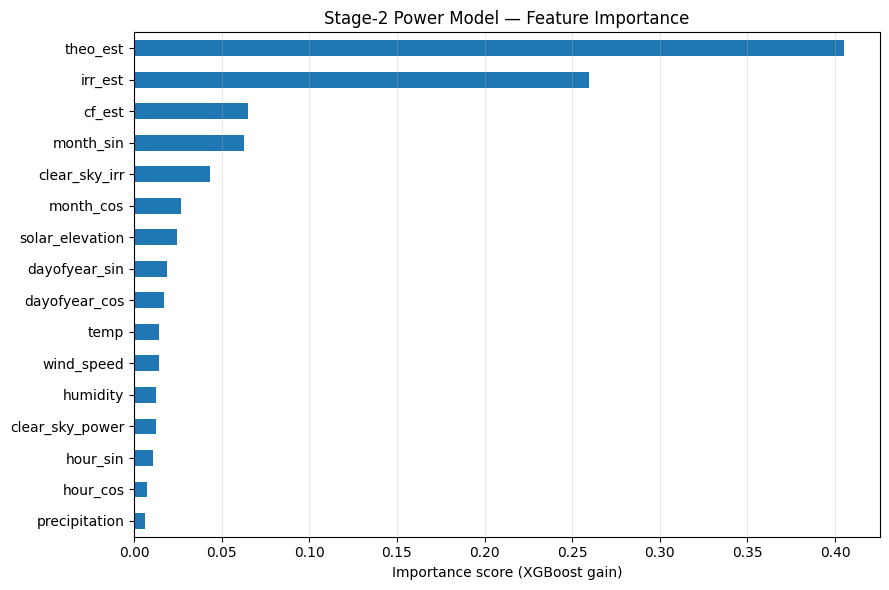


Top features:
theo_est           0.4054
irr_est            0.2596
cf_est             0.0650
month_sin          0.0624
clear_sky_irr      0.0434
month_cos          0.0269
solar_elevation    0.0242
dayofyear_sin      0.0186
dayofyear_cos      0.0173
temp               0.0141
wind_speed         0.0139
humidity           0.0124
clear_sky_power    0.0123
hour_sin           0.0106
hour_cos           0.0075
precipitation      0.0065
dtype: float32


In [81]:
fi = pd.Series(power_model.feature_importances_, index=POWER_FEATS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind="barh", ax=ax)
ax.set_title("Stage-2 Power Model — Feature Importance")
ax.set_xlabel("Importance score (XGBoost gain)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop features:")
print(fi.sort_values(ascending=False).round(4))


## 12. Actual vs predicted — test period

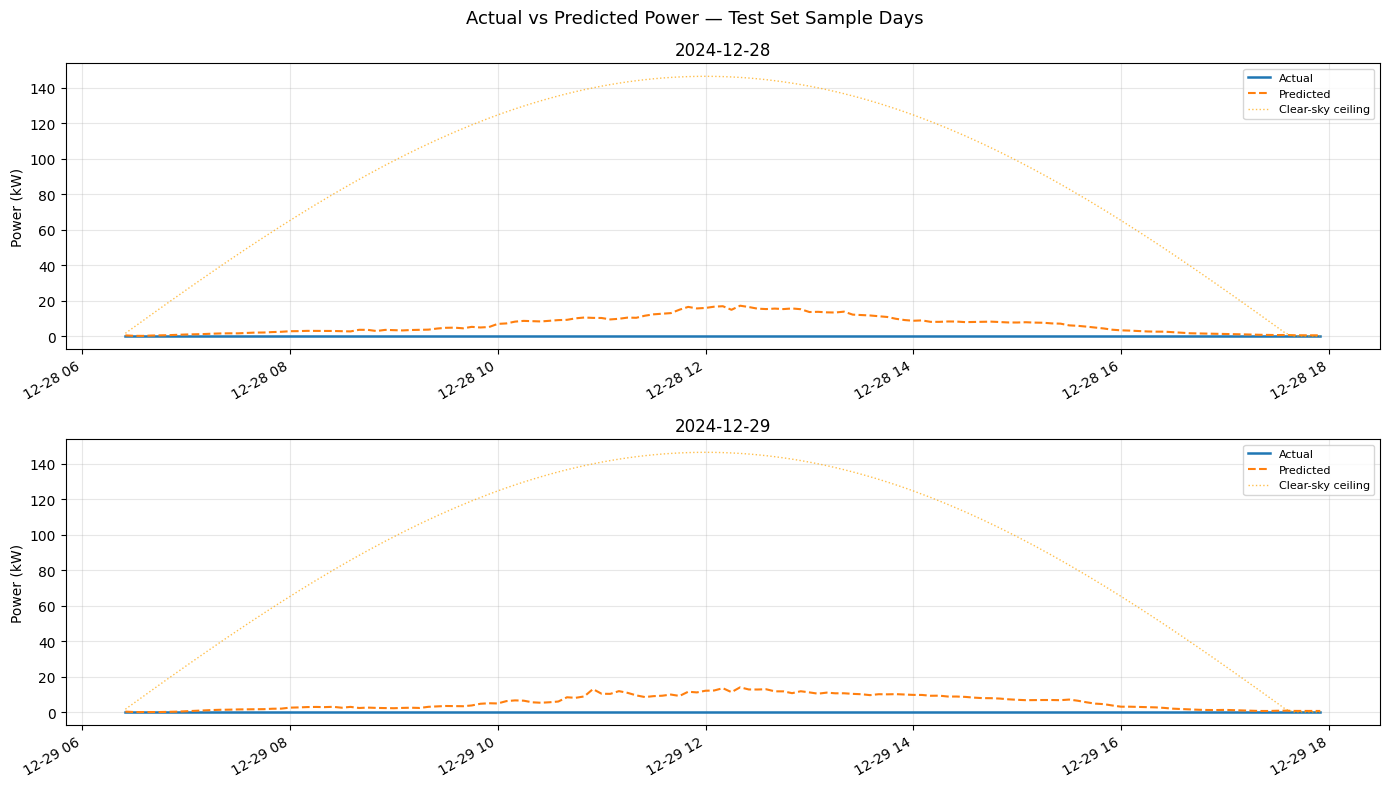

In [92]:
# Pick 3 representative days from the test set for a detailed time-series view
sample_dates = test["time"].dt.date.unique()[:2]

fig, axes = plt.subplots(len(sample_dates), 1, figsize=(14, 4 * len(sample_dates)))
if len(sample_dates) == 1:
    axes = [axes]

for ax, d in zip(axes, sample_dates):
    day_df = test[test["time"].dt.date == d]
    ax.plot(day_df["time"], day_df["power"],           label="Actual",    lw=1.8)
    ax.plot(day_df["time"], day_df["predicted_power"], label="Predicted", lw=1.5, linestyle="--")
    ax.plot(day_df["time"], day_df["clear_sky_power"], label="Clear-sky ceiling", lw=1,
            linestyle=":", color="orange", alpha=0.7)
    ax.set_title(str(d))
    ax.set_ylabel("Power (kW)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle("Actual vs Predicted Power — Test Set Sample Days", fontsize=13)
plt.tight_layout()
plt.show()


## 13. Scatter plot: actual vs predicted

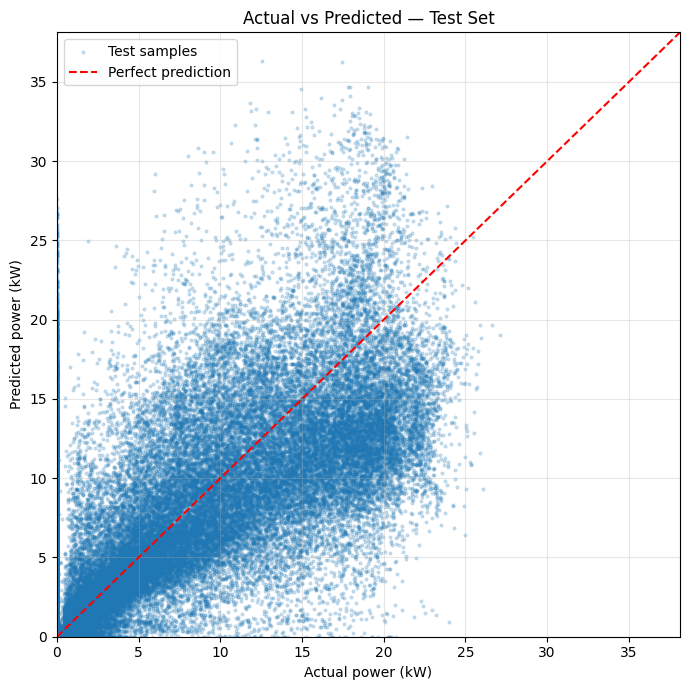

In [93]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(test["power"].fillna(0), test["predicted_power"],
           alpha=0.2, s=4, rasterized=True, label="Test samples")

lim = max(test["power"].max(), test["predicted_power"].max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect prediction")

ax.set_xlabel("Actual power (kW)")
ax.set_ylabel("Predicted power (kW)")
ax.set_title("Actual vs Predicted — Test Set")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()


## 14. Prediction function

```
Input  : timestamp, temp, humidity, wind_speed, precipitation
Output : predicted_power (kW)
```

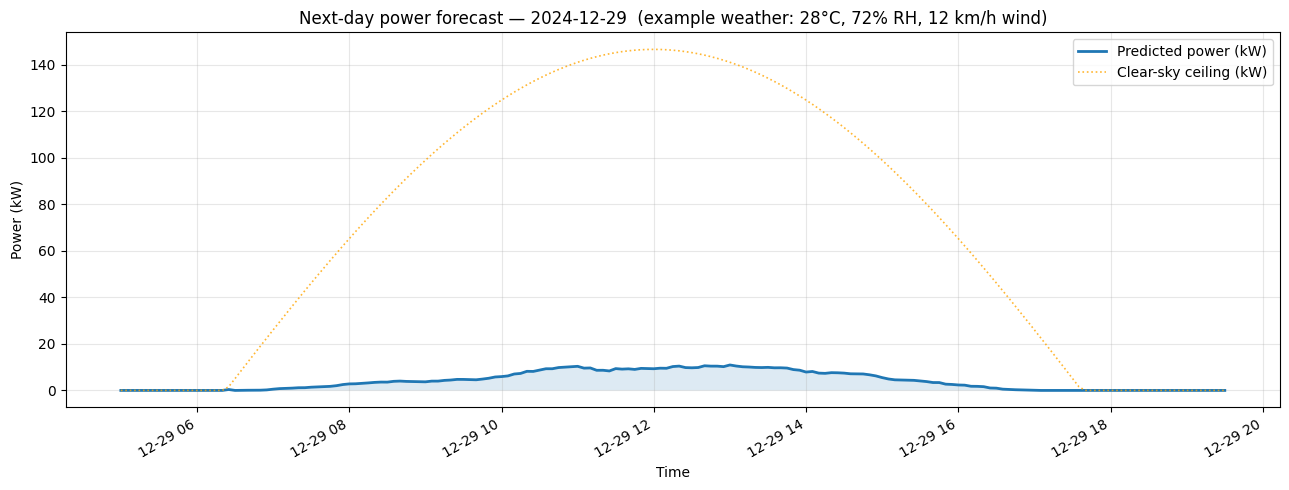


Peak predicted power : 10.94 kW
Total energy today   : 59.39 kWh

               time  predicted_power  irr_est   cf_est  clear_sky_power
2024-12-29 05:00:00              0.0      0.0 0.248553              0.0
2024-12-29 05:05:00              0.0      0.0 0.241306              0.0
2024-12-29 05:10:00              0.0      0.0 0.238343              0.0
2024-12-29 05:15:00              0.0      0.0 0.237507              0.0
2024-12-29 05:20:00              0.0      0.0 0.237041              0.0
2024-12-29 05:25:00              0.0      0.0 0.236201              0.0
2024-12-29 05:30:00              0.0      0.0 0.235831              0.0
2024-12-29 05:35:00              0.0      0.0 0.235831              0.0
2024-12-29 05:40:00              0.0      0.0 0.237098              0.0
2024-12-29 05:45:00              0.0      0.0 0.196430              0.0


In [94]:
def predict_power(timestamps, temp, humidity, wind_speed, precipitation):
    """
    Predict solar power output from weather forecast data.

    Parameters
    ----------
    timestamps    : list/array of datetime-like values
    temp          : air temperature (°C)
    humidity      : relative humidity (%)
    wind_speed    : wind speed (km/h)
    precipitation : precipitation (mm)

    Returns
    -------
    pd.DataFrame with columns: time, predicted_power (kW), irr_est (W/m²), cf_est
    """
    inp = pd.DataFrame({
        "time"          : pd.to_datetime(timestamps),
        "temp"          : temp,
        "humidity"      : humidity,
        "wind_speed"    : wind_speed,
        "precipitation" : precipitation,
    })

    # ── Time features ──────────────────────────────────────────────────────
    inp["hour"]      = inp["time"].dt.hour + inp["time"].dt.minute / 60
    inp["dayofyear"] = inp["time"].dt.dayofyear
    inp["month"]     = inp["time"].dt.month
    for col, period in [("hour", 24), ("dayofyear", 365), ("month", 12)]:
        inp[f"{col}_sin"] = np.sin(2 * np.pi * inp[col] / period)
        inp[f"{col}_cos"] = np.cos(2 * np.pi * inp[col] / period)

    # ── Solar geometry ──────────────────────────────────────────────────────
    lat_r = np.radians(LATITUDE)
    decl  = np.radians(23.45) * np.sin(np.radians((360 / 365) * (inp["dayofyear"] - 81)))
    ha    = np.radians(15 * (inp["hour"] - 12))
    se    = np.sin(lat_r) * np.sin(decl) + np.cos(lat_r) * np.cos(decl) * np.cos(ha)
    inp["solar_elevation"] = np.degrees(np.arcsin(np.clip(se, -1, 1)))
    inp["clear_sky_irr"]   = np.clip(1000 * se, 0, 1100)
    inp["clear_sky_power"] = inp["clear_sky_irr"] * AREA_EFF_M2 / 1000

    # ── Stage 1: estimate cloud factor → irradiance ────────────────────────
    inp["cf_est"]   = np.clip(irr_model.predict(inp[WEATHER_TIME_FEATS]), 0, 1.2)
    inp["irr_est"]  = (inp["clear_sky_irr"] * inp["cf_est"]).clip(0, 1400)
    inp["theo_est"] = inp["irr_est"] * AREA_EFF_M2 / 1000

    # ── Stage 2: predict power ─────────────────────────────────────────────
    raw_pred = power_model.predict(inp[POWER_FEATS])
    inp["predicted_power"] = np.clip(raw_pred, 0, None)

    # Physics constraint: zero power when sun is below horizon
    inp.loc[inp["solar_elevation"] <= 0, "predicted_power"] = 0.0

    return inp[["time", "predicted_power", "irr_est", "cf_est", "clear_sky_power"]]


# ── Demo: forecast next day using example weather values ──────────────────
import datetime as dt
tomorrow = test["time"].min().date() + dt.timedelta(days=1)
times_5min = pd.date_range(
    start=f"{tomorrow} 05:00",
    end  =f"{tomorrow} 19:30",
    freq ="5min"
)

# Example: constant weather values (replace with actual forecast)
example_forecast = predict_power(
    timestamps    = times_5min,
    temp          = np.full(len(times_5min), 28.0),
    humidity      = np.full(len(times_5min), 72.0),
    wind_speed    = np.full(len(times_5min), 12.0),
    precipitation = np.zeros(len(times_5min)),
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(example_forecast["time"], example_forecast["predicted_power"],
        lw=2, label="Predicted power (kW)")
ax.plot(example_forecast["time"], example_forecast["clear_sky_power"],
        lw=1.2, linestyle=":", color="orange", alpha=0.8, label="Clear-sky ceiling (kW)")
ax.fill_between(example_forecast["time"], 0,
                example_forecast["predicted_power"], alpha=0.15)
ax.set_title(f"Next-day power forecast — {tomorrow}  (example weather: 28°C, 72% RH, 12 km/h wind)")
ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time")
ax.legend()
ax.grid(alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"\nPeak predicted power : {example_forecast['predicted_power'].max():.2f} kW")
print(f"Total energy today   : {example_forecast['predicted_power'].sum() * 5/60:.2f} kWh")
print()
print(example_forecast.head(10).to_string(index=False))


## 15. Save models

In [95]:
import pickle, os

save_dir = r"C:\\Solar_SUDHA_maam\\models"
os.makedirs(save_dir, exist_ok=True)

irr_path   = os.path.join(save_dir, "irr_model.pkl")
power_path = os.path.join(save_dir, "power_model.pkl")

with open(irr_path,   "wb") as f: pickle.dump(irr_model,   f)
with open(power_path, "wb") as f: pickle.dump(power_model, f)

print(f"Irradiance model saved → {irr_path}")
print(f"Power model saved      → {power_path}")
print()
print("To reload:")
print("""
    import pickle
    with open(irr_path,   'rb') as f: irr_model   = pickle.load(f)
    with open(power_path, 'rb') as f: power_model = pickle.load(f)
    # Then call predict_power(...) as shown in Cell 14
""")


Irradiance model saved → C:\\Solar_SUDHA_maam\\models\irr_model.pkl
Power model saved      → C:\\Solar_SUDHA_maam\\models\power_model.pkl

To reload:

    import pickle
    with open(irr_path,   'rb') as f: irr_model   = pickle.load(f)
    with open(power_path, 'rb') as f: power_model = pickle.load(f)
    # Then call predict_power(...) as shown in Cell 14



Expanded to 169 five-minute rows
Date range : 2026-06-11 05:00:00  →  2026-06-11 19:00:00

Sample interpolated rows:
               time  temp  humidity  wind_speed  precipitation
2026-06-11 06:00:00  27.0      86.0         5.5            0.0
2026-06-11 06:05:00  27.0      86.0         5.5            0.0
2026-06-11 06:10:00  27.0      86.0         5.5            0.0
2026-06-11 06:15:00  27.0      86.0         5.5            0.0
2026-06-11 06:20:00  27.0      86.0         5.5            0.0
2026-06-11 06:25:00  27.0      86.0         5.5            0.0

  FORECAST SUMMARY — 2026-06-11  (VIT Chennai)
  Peak power         : 14.69 kW  at 10:40
  Clear-sky ceiling  : 178.81 kW
  Total energy       : 99.44 kWh
  Capacity factor    : 2.8%  (full day avg)
  Mean irr estimate  : 226 W/m²
  Mean cloud factor  : 0.308  (0=overcast, 1=clear)

Five-minute forecast table:
               time  predicted_power  irr_est  cf_est  clear_sky_power
2026-06-11 05:00:00            0.000    0.000   0.262     

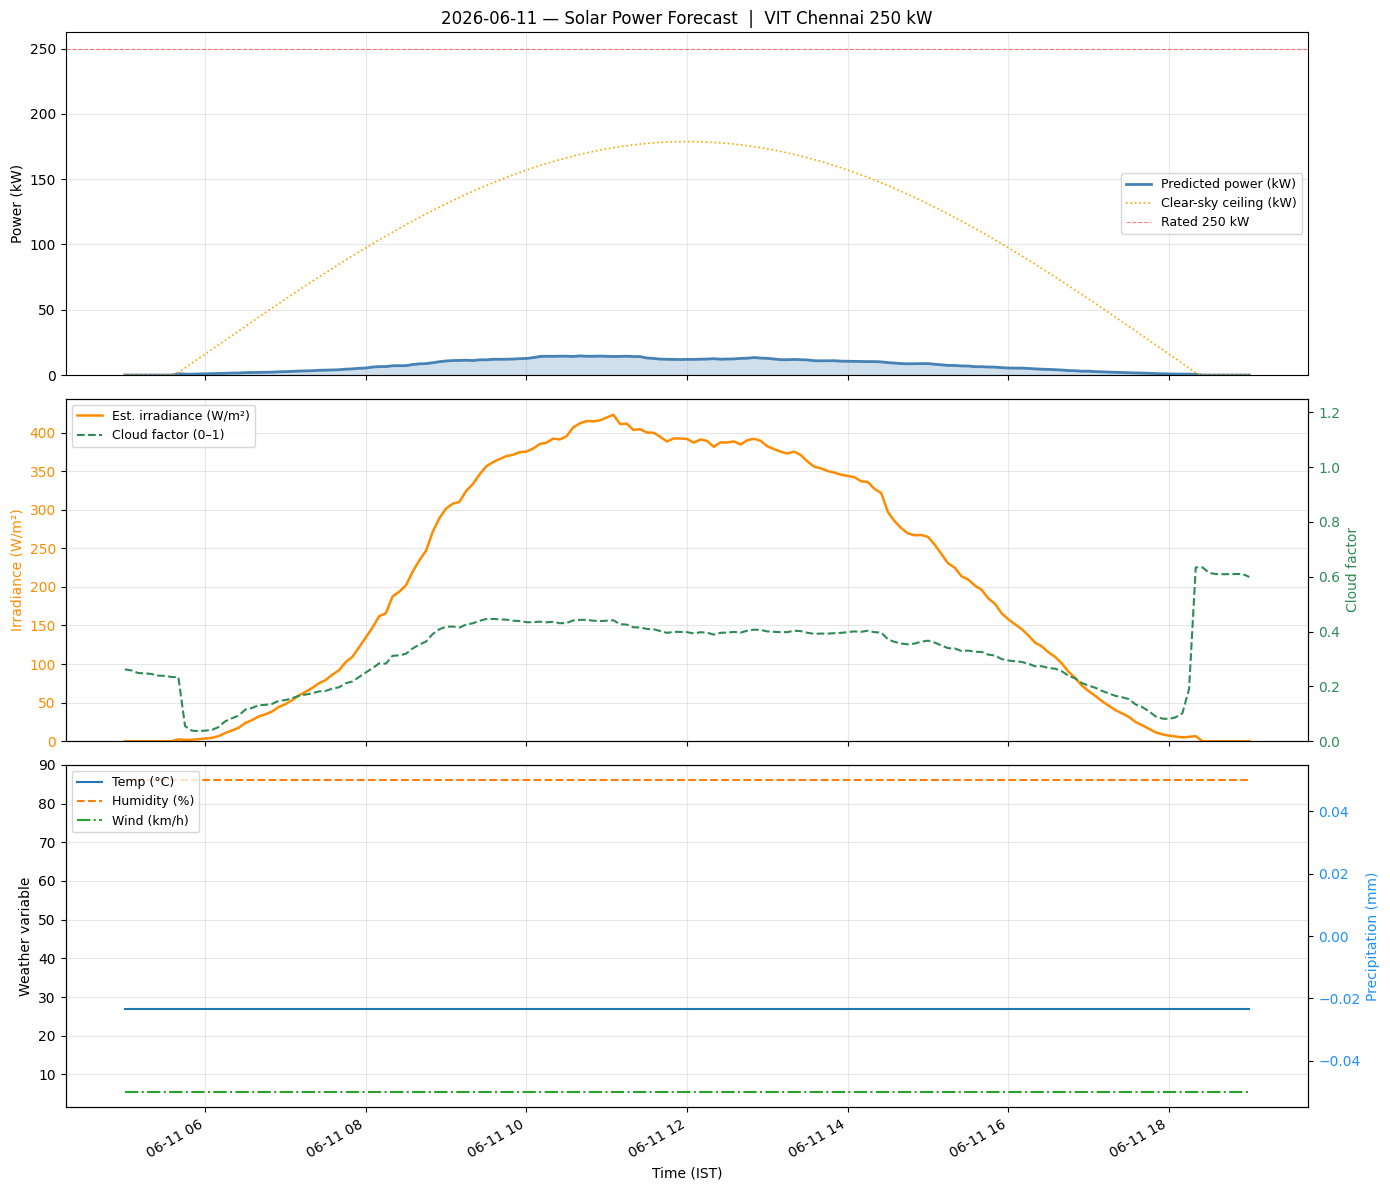

In [96]:
# Standalone test — paste after training the notebook models
# Requires: predict_power(), RATED_KW, AREA_EFF_M2 already defined

# ═══════════════════════════════════════════════════════════════
#  TEST CELL — Forecast for 2026-06-11 using hourly weather data
#  Run this AFTER all cells above have been executed.
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import PchipInterpolator

# ── 1. Raw hourly forecast data ─────────────────────────────────────────────
# Columns: timestamp (ISO), temp (°C), humidity (%), wind_speed (km/h), precipitation (mm)
data = [
    ("2026-02-10T23:00", 28.1, 80,  6.1, 0  ),
    ("2026-02-11T00:00", 27.8, 81,  4.4, 0  ),
    ("2026-02-11T01:00", 27.5, 82,  4.8, 0.1),
    ("2026-02-11T02:00", 27.5, 82,  4.9, 0  ),
    ("2026-02-11T03:00", 26.9, 85,  4.0, 0  ),
    ("2026-02-11T04:00", 26.5, 88,  5.4, 0  ),
    ("2026-02-11T05:00", 26.5, 89,  5.6, 0.1),
    ("2026-02-11T06:00", 27.5, 83,  4.8, 0  ),
    ("2026-02-11T07:00", 28.5, 77,  6.2, 0.1),
    ("2026-02-11T08:00", 29.5, 73, 10.2, 0.1),
    ("2026-02-11T09:00", 29.5, 71, 11.0, 1.6),
    ("2026-02-11T10:00", 29.3, 73, 10.2, 0.4),
    ("2026-02-11T11:00", 31.2, 64, 13.3, 0  ),
    ("2026-02-11T12:00", 31.5, 64, 13.7, 0  ),
    ("2026-02-11T13:00", 31.8, 63, 14.4, 0  ),
    ("2026-02-11T14:00", 31.5, 64, 15.2, 0  ),
    ("2026-02-11T15:00", 31.1, 65, 14.8, 0  ),
    ("2026-02-11T16:00", 30.2, 70, 14.9, 0  ),
    ("2026-02-11T17:00", 29.2, 71, 13.4, 0  ),
    ("2026-02-11T18:00", 28.1, 78, 11.3, 0  ),
    ("2026-02-11T19:00", 28.0, 81,  8.9, 0  ),
    ("2026-02-11T20:00", 27.8, 83,  7.6, 0  ),
    ("2026-02-11T21:00", 27.6, 84,  5.7, 0  ),
    ("2026-02-11T22:00", 27.1, 87,  4.4, 0  ),
    ("2026-02-11T23:00", 27.0, 87,  5.4, 0  ),
    ("2026-02-12T00:00", 27.0, 86,  5.5, 0  ),
]

hourly = pd.DataFrame(data, columns=["time", "temp", "humidity", "wind_speed", "precipitation"])
hourly["time"] = pd.to_datetime(hourly["time"])

# ── 2. Expand hourly → 5-minute using segment-wise PCHIP ────────────────────
# Covers the full solar day for Chennai on Jun 11 (sunrise ~05:30, sunset ~18:45)
t_5min = pd.date_range("2026-06-11 05:00", "2026-06-11 19:00", freq="5min")

# Convert timestamps to integer seconds for interpolation
t_h = hourly["time"].astype("int64") // 10**9
t_q = t_5min.astype("int64")         // 10**9

five_min = pd.DataFrame({"time": t_5min})

# PCHIP for continuous met variables (smooth, no overshoot)
for col in ["temp", "humidity", "wind_speed"]:
    fn = PchipInterpolator(t_h, hourly[col].values, extrapolate=False)
    vals = fn(t_q)
    # Fill any NaN at boundaries with nearest hourly value
    vals = np.where(np.isnan(vals), np.interp(t_q, t_h, hourly[col].values), vals)
    five_min[col] = vals.round(3)

# Physical bounds after interpolation
five_min["humidity"]    = five_min["humidity"].clip(0, 100)
five_min["wind_speed"]  = five_min["wind_speed"].clip(0)

# Precipitation: distribute hourly total evenly across its 12 five-minute slots
prec_5min = np.zeros(len(t_5min))
for _, row in hourly.iterrows():
    hour_floor = row["time"].floor("h")
    slot_mask  = (five_min["time"].dt.floor("h") == hour_floor).values
    n_slots    = slot_mask.sum()
    if n_slots > 0 and row["precipitation"] > 0:
        prec_5min[slot_mask] = row["precipitation"] / n_slots
five_min["precipitation"] = np.round(prec_5min, 4)

print(f"Expanded to {len(five_min)} five-minute rows")
print(f"Date range : {five_min['time'].iloc[0]}  →  {five_min['time'].iloc[-1]}")
print()
print("Sample interpolated rows:")
print(five_min[["time","temp","humidity","wind_speed","precipitation"]].iloc[12:18].to_string(index=False))

# ── 3. Run the two-stage prediction pipeline ────────────────────────────────
result = predict_power(
    timestamps    = five_min["time"],
    temp          = five_min["temp"].values,
    humidity      = five_min["humidity"].values,
    wind_speed    = five_min["wind_speed"].values,
    precipitation = five_min["precipitation"].values,
)

# ── 4. Summary statistics ────────────────────────────────────────────────────
daytime = result[result["clear_sky_power"] > 0.5].copy()
peak_idx  = daytime["predicted_power"].idxmax()
peak_row  = daytime.loc[peak_idx]
total_kwh = (result["predicted_power"].sum() * 5 / 60)   # kW × 5-min → kWh

print()
print("=" * 52)
print("  FORECAST SUMMARY — 2026-06-11  (VIT Chennai)")
print("=" * 52)
print(f"  Peak power         : {peak_row['predicted_power']:.2f} kW  at {peak_row['time'].strftime('%H:%M')}")
print(f"  Clear-sky ceiling  : {daytime['clear_sky_power'].max():.2f} kW")
print(f"  Total energy       : {total_kwh:.2f} kWh")
print(f"  Capacity factor    : {(result['predicted_power'].mean() / RATED_KW * 100):.1f}%  (full day avg)")
print(f"  Mean irr estimate  : {daytime['irr_est'].mean():.0f} W/m²")
print(f"  Mean cloud factor  : {daytime['cf_est'].mean():.3f}  (0=overcast, 1=clear)")
print("=" * 52)
print()
print("Five-minute forecast table:")
display_cols = ["time", "predicted_power", "irr_est", "cf_est", "clear_sky_power"]
print(result[display_cols].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ── 5. Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# — Panel A: Predicted power vs clear-sky ceiling —
ax = axes[0]
ax.fill_between(result["time"], 0, result["predicted_power"], alpha=0.25, color="steelblue")
ax.plot(result["time"], result["predicted_power"],
        lw=2, color="steelblue", label="Predicted power (kW)")
ax.plot(result["time"], result["clear_sky_power"],
        lw=1.2, color="orange", linestyle=":", label="Clear-sky ceiling (kW)")
ax.axhline(RATED_KW, color="red", lw=0.8, linestyle="--", alpha=0.5, label=f"Rated {RATED_KW} kW")
ax.set_ylabel("Power (kW)")
ax.set_title("2026-06-11 — Solar Power Forecast  |  VIT Chennai 250 kW")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0)

# — Panel B: Estimated irradiance and cloud factor —
ax2 = axes[1]
color_irr = "darkorange"
color_cf  = "seagreen"
ln1 = ax2.plot(result["time"], result["irr_est"], color=color_irr, lw=1.8, label="Est. irradiance (W/m²)")
ax2.set_ylabel("Irradiance (W/m²)", color=color_irr)
ax2.tick_params(axis="y", labelcolor=color_irr)
ax2r = ax2.twinx()
ln2 = ax2r.plot(result["time"], result["cf_est"], color=color_cf, lw=1.5,
                linestyle="--", label="Cloud factor (0–1)")
ax2r.set_ylabel("Cloud factor", color=color_cf)
ax2r.set_ylim(0, 1.25)
ax2r.tick_params(axis="y", labelcolor=color_cf)
lines = ln1 + ln2
ax2.legend(lines, [l.get_label() for l in lines], fontsize=9, loc="upper left")
ax2.grid(alpha=0.3)
ax2.set_ylim(0)

# — Panel C: Interpolated weather inputs —
ax3 = axes[2]
ax3.plot(five_min["time"], five_min["temp"],       lw=1.5, label="Temp (°C)")
ax3.plot(five_min["time"], five_min["humidity"],   lw=1.5, label="Humidity (%)", linestyle="--")
ax3.plot(five_min["time"], five_min["wind_speed"], lw=1.5, label="Wind (km/h)",  linestyle="-.")
ax3_r = ax3.twinx()
ax3_r.bar(five_min["time"], five_min["precipitation"],
          width=pd.Timedelta("4min"), color="dodgerblue", alpha=0.4, label="Precip (mm)")
ax3_r.set_ylabel("Precipitation (mm)", color="dodgerblue")
ax3_r.tick_params(axis="y", labelcolor="dodgerblue")
ax3.set_ylabel("Weather variable")
ax3.set_xlabel("Time (IST)")
ax3.legend(fontsize=9, loc="upper left")
ax3.grid(alpha=0.3)

plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()